## 自動微分(Automatic Differentiation)

In [1]:
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
import torch
from torch.autograd import Variable
from torch.nn import functional as F

In [2]:
# 設定 x 參與自動微分
x = torch.tensor(4.0, requires_grad=True)

y = x**2  # y = x^2

print(y)
print(y.grad_fn)  # y 梯度函數
y.backward()  # 反向傳導
print(x.grad)  # 取得梯度

tensor(16., grad_fn=<PowBackward0>)
tensor(8.)


## 取得變數的自動微分相關屬性值

In [3]:
# 設定變數值
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0)
z = x * y
z.retain_grad()

# 顯示自動微分相關屬性
for i, name in zip([x, y, z], "xyz"):
    print(
        f"{name}\ndata: {i.data}\nrequires_grad: {i.requires_grad}\n"
        + f"grad: {i.grad}\ngrad_fn: {i.grad_fn}\nis_leaf: {i.is_leaf}\n"
    )

x
data: 1.0
requires_grad: True
grad: None
grad_fn: None
is_leaf: True

y
data: 2.0
requires_grad: False
grad: None
grad_fn: None
is_leaf: True

z
data: 2.0
requires_grad: True
grad: None
grad_fn: <MulBackward0 object at 0x10a316ef0>
is_leaf: False



## 交叉熵(cross entropy)範例

## 🕸 交叉熵（Cross-Entropy）損失函數的運算圖與反向傳播

在二分類或多分類任務中，我們通常會將神經網路的原始輸出（Logits）通過 **Softmax 函數** 轉換為機率分佈，再輸入 **交叉熵（Cross-Entropy）** 計算損失。

為了看清這個過程，我們將以**單一數據點的二分類任務**為例，將其拆解為「運算圖」。

---

### 1. 交叉熵的前向傳播運算圖

假設：
*   $y$：真實標籤（取值為 0 或 1）。
*   $a$：模型預測的機率（即經過 Sigmoid 或 Softmax 後的輸出，$0 < a < 1$）。

二分類的交叉熵損失函數公式為：
$$L = - [y \ln(a) + (1-y) \ln(1-a)]$$

我們可以把這個複雜的公式拆解成多個簡單的基礎運算節點（Nodes），建構出以下的前向傳播運算圖：



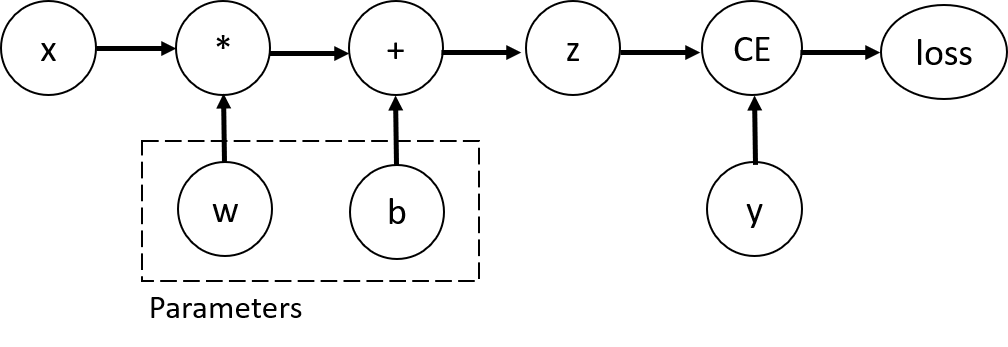

In [4]:
# https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html
from IPython.display import Image

Image('images/cross_entropy.png', width=500)

[真實標籤 y] ───┐│[預測機率 a] ───┼──> [ ln ] ──> ( ln(a) ) ────> [ × ] ──> ( y·ln(a) ) ───┐│                                 ▲                       ││                           ┌─────┘                       ├──> [ + ] ──> ( Sum ) ──> [ ×(-1) ] ──> [ 損失 L ]│                           │                             │└──> [ 1 - ] ─> ( 1-a ) ──> [ ln ] ──> ( ln(1-a) ) ──> [ × ] ──> ( (1-y)·ln(1-a) ) ┘▲[真實標籤 y] ──────────────────────> [ 1 - ] ──> ( 1-y ) ───────────────┘

#### 🏃‍♂️ 前向傳播步驟拆解：
1.  **節點 1：** 計算 $\ln(a)$ 與 $1-a$。
2.  **節點 2：** 計算 $\ln(1-a)$ 與 $1-y$。
3.  **節點 3（乘法）：** 將真實標籤與對數機率相乘，得到 $y \ln(a)$ 和 $(1-y) \ln(1-a)$。
4.  **節點 4（加法）：** 將兩者加總。
5.  **節點 5（常數乘法）：** 乘以 $-1$，輸出最終損失 $L$。

---

### 2. 運算圖的反向傳播（梯度求導）

利用運算圖，我們可以從最右邊的 $L$ 開始，根據**微積分連鎖律（Chain Rule）**「由右向左」推導損失對預測機率 $a$ 的偏微分 $\frac{\partial L}{\partial a}$。

#### 🔄 步驟一：對加法節點前兩項求導
根據常數乘法與加法規則，損失 $L$ 對兩個分支的導數分別為：
*   對左上分支 $(y \ln(a))$ 的導數為 $-1$
*   對右下分支 $((1-y)\ln(1-a))$ 的導數為 $-1$

#### 🔄 步驟二：通過乘法節點向左傳遞
根據乘法求導法則（$\frac{\partial (cu)}{\partial u} = c$）：
*   對 $\ln(a)$ 的導數 = $-1 \cdot y = -y$
*   對 $\ln(1-a)$ 的導數 = $-1 \cdot (1-y) = y - 1$

#### 🔄 步驟三：通過對數與複合節點，匯聚至 $a$
現在，兩條路徑都會匯流回到節點 $a$。我們分別計算兩條路徑對 $a$ 的貢獻：

1.  **上方路徑：** 經過 $\ln(a)$ 節點（微分為 $\frac{1}{a}$）
    $$\text{Grad}_{\text{up}} = -y \cdot \frac{1}{a} = -\frac{y}{a}$$
2.  **下方路徑：** 經過 $\ln(1-a)$ 節點與 $1-a$ 節點（連鎖微分為 $\frac{1}{1-a} \cdot (-1) = -\frac{1}{1-a}$）
    $$\text{Grad}_{\text{down}} = (y - 1) \cdot \left(-\frac{1}{1-a}\right) = \frac{1-y}{1-a}$$

#### 🏁 總結：將兩條路徑合併
將上方與下方路徑的梯度相加，即得到**交叉熵對預測值 $a$ 的最終梯度公式**：

$$\frac{\partial L}{\partial a} = -\frac{y}{a} + \frac{1-y}{1-a}$$

通分後可進一步簡化為：
$$\boxed{\frac{\partial L}{\partial a} = \frac{a - y}{a(1-a)}}$$

> 💡 **驚人的數學巧合：**
> 在神經網路中，$a$ 通常是由 **Sigmoid 函數** $a = \sigma(z)$ 產生的。而 Sigmoid 的微分恰好是 $\frac{\partial a}{\partial z} = a(1-a)$。
> 如果我們繼續往左推導損失對神經網路原始輸出 $z$ 的梯度，根據連鎖律：
> $$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} = \frac{a - y}{a(1-a)} \cdot a(1-a) = \boxed{a - y}$$
> 分母完美的被抵消了！這就是為什麼**交叉熵 + Sigmoid/Softmax** 是機器學習最完美絕配的原因，因為它帶來的梯度極其簡單且優雅。

In [5]:
x = torch.ones(5)
y = torch.zeros(3)
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w) + b
loss = F.binary_cross_entropy_with_logits(z, y)

print('z 梯度函數：', z.grad_fn)
print('loss 梯度函數：', loss.grad_fn)

z 梯度函數： <AddBackward0 object at 0x137c94910>
loss 梯度函數： <BinaryCrossEntropyWithLogitsBackward0 object at 0x10a317a00>


In [6]:
loss.backward()
print(w.grad)  # w梯度值
print(b.grad)  # b梯度值

tensor([[0.2694, 0.2990, 0.1036],
        [0.2694, 0.2990, 0.1036],
        [0.2694, 0.2990, 0.1036],
        [0.2694, 0.2990, 0.1036],
        [0.2694, 0.2990, 0.1036]])
tensor([0.2694, 0.2990, 0.1036])


In [7]:
# Variable 在 v0.4.0已被棄用，直接使用 tensor 即可
x = Variable(torch.ones(1), requires_grad=True)
y = x + 1
y.backward()
print(x.grad)

tensor([1.])


In [8]:
# 替代 Variable
x2 = torch.ones(1, requires_grad=True)
y = x2 + 1
y.backward()
print(x2.grad)

tensor([1.])


## 多次梯度下降

In [9]:
x = torch.tensor(5.0, requires_grad=True)
y = x**3  # y = x^3

y.backward(retain_graph=True)  # 梯度下降
print(f'一次梯度下降={x.grad}')

y.backward(retain_graph=True)  # 梯度下降
print(f'二次梯度下降={x.grad}')

y.backward()  # 梯度下降
print(f'三次梯度下降={x.grad}')

一次梯度下降=75.0
二次梯度下降=150.0
三次梯度下降=225.0


## 梯度 reset

In [10]:
x = torch.tensor(5.0, requires_grad=True)
y = x**3  # y = x^3

y.backward(retain_graph=True)  # 梯度下降
print(f'一次梯度下降={x.grad}')
assert x.grad is not None
x.grad.zero_()  # 梯度 reset

y.backward(retain_graph=True)  # 梯度下降
print(f'二次梯度下降={x.grad}')
x.grad.zero_()  # 梯度 reset

y.backward()  # 梯度下降
print(f'三次梯度下降={x.grad}')

一次梯度下降=75.0
二次梯度下降=75.0
三次梯度下降=75.0


## 多個變數梯度下降

In [11]:
x = torch.tensor(5.0, requires_grad=True)
y = x**3  # y = x^3
z = y**2  # z = y^2

z.backward()  # 梯度下降
print(f'x 梯度下降 = {x.grad}')  # 6 * x^5

x 梯度下降 = 18750.0


## 梯度下降法(Gradient Descent)

[5.   2.   0.8  0.32 0.13 0.05 0.02 0.01 0.   0.   0.   0.   0.   0.
 0.   0.  ]


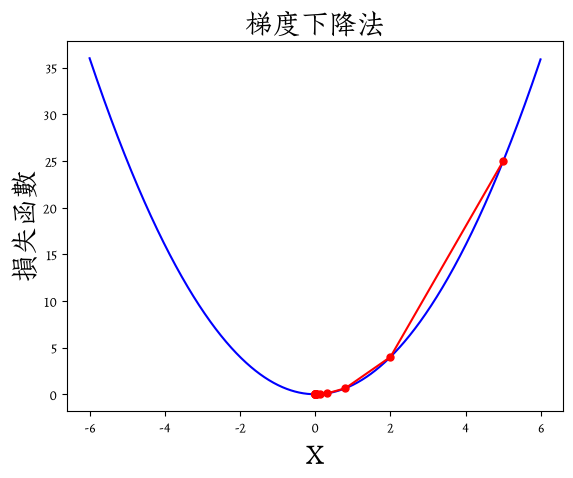

In [12]:
# 目標函數(損失函數):y=x^2
def func(x: float | np.ndarray):
    return x**2


# 目標函數的一階導數:dy/dx=2*x
def dfunc(x: float | np.ndarray):
    return 2 * x


# 超參數(Hyperparameters)
x_start = 5  # 起始權重
epochs = 15  # 執行週期數
lr = 0.3  # 學習率


# 梯度下降法
def GD(
    x_start: float,
    df: Callable[[float | np.ndarray], float | np.ndarray],
    epochs: int,
    lr: float,
) -> np.ndarray:
    xs = np.zeros(epochs + 1)
    x = x_start
    xs[0] = x
    for i in range(epochs):
        dx = df(x)
        # 更新 x_new = x — learning_rate * gradient
        x -= dx * lr
        xs[i + 1] = x
    return xs


# *** Function 可以直接當參數傳遞 ***
w = GD(x_start, dfunc, epochs, lr=lr)
print(np.around(w, 2))

t = np.arange(-6.0, 6.0, 0.01)
plt.plot(t, func(t), c='b')
plt.plot(w, func(w), c='r', marker='o', markersize=5)

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 正黑體
plt.rcParams['axes.unicode_minus'] = False  # 矯正負號

plt.title('梯度下降法', fontsize=20)
plt.xlabel('X', fontsize=20)
plt.ylabel('損失函數', fontsize=20)
plt.show()

## 使用 PyTorch

[5.   2.   0.8  0.32 0.13 0.05 0.02 0.01 0.   0.   0.   0.   0.   0.
 0.   0.  ]


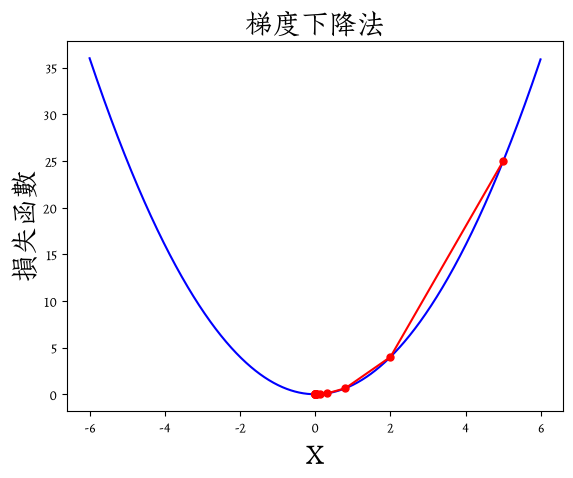

In [13]:
# 目標函數(損失函數):y=x^2
def func(x: float | np.ndarray):
    return x**2


# 自動微分
def dfunc(x: float | np.ndarray | torch.Tensor):
    x_tensor = torch.tensor(float(x), requires_grad=True)
    y = x_tensor**2  # 目標函數(損失函數)
    y.backward()
    assert x_tensor.grad is not None
    return x_tensor.grad


# 超參數(Hyperparameters)
x_start = 5  # 起始權重
epochs = 15  # 執行週期數
lr = 0.3  # 學習率


# 梯度下降法
def GD(
    x_start: float,
    df: Callable[[float | np.ndarray | torch.Tensor], torch.Tensor],
    epochs: int,
    lr: float,
) -> np.ndarray:
    xs = np.zeros(epochs + 1)
    x = x_start
    xs[0] = x
    for i in range(epochs):
        dx = df(x)
        # x更新 x_new = x — learning_rate * gradient
        x -= dx * lr
        xs[i + 1] = x
    return xs


# *** Function 可以直接當參數傳遞 ***
w = GD(x_start, dfunc, epochs, lr=lr)
print(np.around(w, 2))

t = np.arange(-6.0, 6.0, 0.01)
plt.plot(t, func(t), c='b')
plt.plot(w, func(w), c='r', marker='o', markersize=5)

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 正黑體
plt.rcParams['axes.unicode_minus'] = False  # 矯正負號

plt.title('梯度下降法', fontsize=20)
plt.xlabel('X', fontsize=20)
plt.ylabel('損失函數', fontsize=20)
plt.show()

[5.   4.03 3.53 ... 0.51 0.51 0.51]


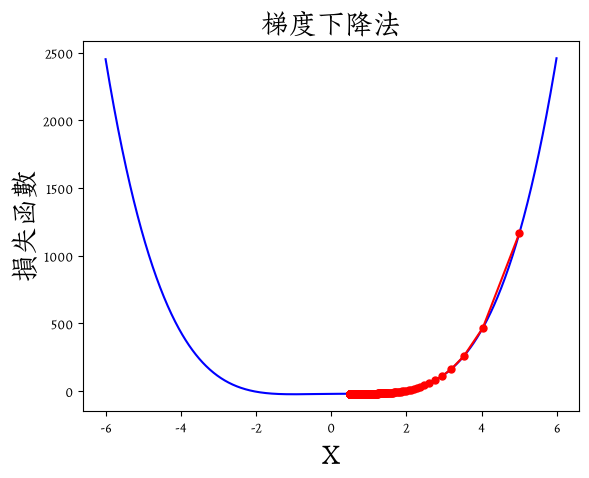

In [14]:
# 損失函數
def func(x: float | np.ndarray):
    return 2 * x**4 - 3 * x**2 + 2 * x - 20


# 自動微分
def dfunc(x: float | np.ndarray | torch.Tensor):
    x = torch.tensor(float(x), requires_grad=True)
    y = 2 * x**4 - 3 * x**2 + 2 * x - 20
    y.backward()
    assert x.grad is not None
    return x.grad


# 超參數(Hyperparameters)
x_start = 5  # 起始權重
epochs = 15000  # 執行週期數
lr = 0.001  # 學習率

# *** Function 可以直接當參數傳遞 ***
w = GD(x_start, dfunc, epochs, lr=lr)
print(np.around(w, 2))

t = np.arange(-6.0, 6.0, 0.01)
plt.plot(t, func(t), c='b')
plt.plot(w, func(w), c='r', marker='o', markersize=5)

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 正黑體
plt.rcParams['axes.unicode_minus'] = False  # 矯正負號

plt.title('梯度下降法', fontsize=20)
plt.xlabel('X', fontsize=20)
plt.ylabel('損失函數', fontsize=20)
plt.show()

## 使用 TensorFlow

[5.   2.   0.8  0.32 0.13 0.05 0.02 0.01 0.   0.   0.   0.   0.   0.
 0.   0.  ]


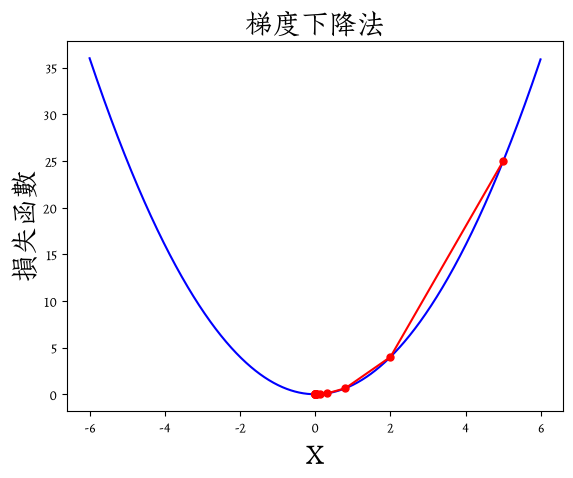

In [15]:
# 目標函數(損失函數):y=x^2
def func(x: float | np.ndarray):
    return x**2


# 自動微分
def dfunc(x_value: float | np.ndarray):
    x = tf.Variable(tf.constant(x_value, dtype=tf.float32))  # 宣告 TensorFlow 變數(Variable)
    with tf.GradientTape() as g:  # 自動微分
        y = x**2  # y = x^2
    dy_dx = g.gradient(y, x)  # 取得梯度
    assert isinstance(dy_dx, tf.Tensor)
    return dy_dx.numpy()  # 轉成 NumPy array


# 超參數(Hyperparameters)
x_start = 5  # 起始權重
epochs = 15  # 執行週期數
lr = 0.3  # 學習率


# 梯度下降法
def GD(
    x_start: float,
    df: Callable[[float | np.ndarray], np.ndarray],
    epochs: int,
    lr: float,
) -> np.ndarray:
    xs = np.zeros(epochs + 1)
    x = x_start
    xs[0] = x
    for i in range(epochs):
        dx = df(x)
        # x更新 x_new = x — learning_rate * gradient
        x -= dx * lr
        xs[i + 1] = x
    return xs


# *** Function 可以直接當參數傳遞 ***
w = GD(x_start, dfunc, epochs, lr=lr)
print(np.around(w, 2))

t = np.arange(-6.0, 6.0, 0.01)
plt.plot(t, func(t), c='b')
plt.plot(w, func(w), c='r', marker='o', markersize=5)

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 正黑體
plt.rcParams['axes.unicode_minus'] = False  # 矯正負號

plt.title('梯度下降法', fontsize=20)
plt.xlabel('X', fontsize=20)
plt.ylabel('損失函數', fontsize=20)
plt.show()